# Clustering: MSE no Rel 100 

In [1]:
import joblib
import os
import time

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

from astroExplain.spectra import clustering
from astroExplain.spectra import astronomy
from sdss.metadata import MetaData

meta = MetaData()

In [2]:
n_spec_bin_03 = 181_850
n_top_1_percent = int(n_spec_bin_03 * 0.01)
n_top_5_percent = int(n_spec_bin_03 * 0.05)
n_top_1_percent, n_top_5_percent
# n_top_1_percent = 1806

(1818, 9092)

# Custom functions

## Data ingestion

In [3]:
def data_ingestion(
    metric, n_segments,
    run_id, bin_id,
    explanations_dir, spectra_dir
):
    """
    Function to load the data for a given metric and run_id.
    """

    data_dict = {
        "metric": metric,
        "run_id": run_id,
        "weights": None,
        "norm_weights": None,
        "unique_weights": None,
        "norm_unique_weights": None,
        "anomalies": None,
        "anomalies_df": None,
    }

    data_dict["weights"] = np.load(
        f"{explanations_dir}/{bin_id}/"
        f"{data_dict['metric']}/"
        f"weights_{data_dict['run_id']}.npy"
    )

    data_dict["norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["weights"]
    )

    data_dict["unique_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["weights"],
        n_segments=n_segments,
    )
    data_dict["norm_unique_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["unique_weights"]
    )

    data_dict["anomalies"] = np.load(
        f"{spectra_dir}/{bin_id}/"
        f"{data_dict['metric']}/top_anomalies.npy",
        mmap_mode="r"
    )

    data_dict["anomalies_df"] = pd.read_csv(
        f"{spectra_dir}/{bin_id}/"
        f"{data_dict['metric']}/top_anomalies.csv.gz",
        index_col="specobjid",
    )

    return data_dict

## Spec with thumbnails

In [4]:
def spec_photo_thumbnail(
    ax,
    wave, spec,
    photo_img=None,
    width_height_image='100%',
    bbox_to_anchor=(0.695, 0.52, 0.5, 0.5),
    # loc="upper right",
    add_image=False,
):

    ax.plot(wave, spec, color='black')
    # Create inset in top-right corner of figure

    ax.set_xlim(350, 770)
    wave_ticks = list(np.arange(400, 751, 50))
    ax.set_xticks(wave_ticks)

    if add_image is False:
        return ax

    axins = inset_axes(
        ax,
        width=width_height_image, height=width_height_image,
        bbox_to_anchor=bbox_to_anchor,
        bbox_transform=ax.transAxes,
        # loc=loc
    )

    # Show image in the inset
    axins.imshow(photo_img)
    axins.axis('off')  # Hide axis around the image

    return ax, axins


## Lines indicators

In [5]:
GALAXY_LINES_NM = {
    'OII': {'name': 'OII', 'line_wave': 372.7},
    # 'NeIII': {'name': 'NeIII', 'line_wave': 386.9},
    # 'HI': {'name': 'HI', 'line_wave': 388.9},
    'H_epsilon': {'name': r'H$\epsilon$', 'line_wave': 397},
    'H_delta': {'name': r'H$\delta$', 'line_wave': 410.2},
    'H_gamma': {'name': r'H$\gamma$', 'line_wave': 434.0},
    'H_beta': {'name': r'H$\beta$', 'line_wave': 486.1},
    'OIII': {'name': 'OIII', 'line_wave': 500.7},
    'H_alpha': {'name': r'H$\alpha$', 'line_wave': 656.3},
    'SII': {'name': 'SII', 'line_wave': 673},
    # 'SII': 671.6
}


In [6]:
def add_line_indicators(
    ax, wave, spec,
    indicator_starts,
    indicator_height,
    add_ne3_he1=False,
    add_h_epsilon=False,
    add_h_delta=False,
    add_h_gamma=False,
    add_h_beta=False,
    add_sii=False,
    delta=1,
    indicator_color='blue',
    indicator_label_color='black',
    lw=1,
    fontsize=6,
):
    
    for line_name, value_dict in GALAXY_LINES_NM.items():
        
        # skip desired lines
        if line_name == 'H_epsilon' and add_h_epsilon is False:
            continue

        if line_name == 'H_delta' and add_h_delta is False:
            continue

        if line_name == 'H_gamma' and add_h_gamma is False:
            continue

        if line_name == 'H_beta' and add_h_beta is False:
            continue

        if line_name == 'SII' and add_sii is False:
            continue

        line_wave = value_dict['line_wave']
        # Find the flux value of the spectrum at the line's wavelength
        # get small neigborhood among line_wave
        # get max flux there and set as line_flux
        line_flux = np.max(
            spec[(wave > line_wave - delta) & (wave < line_wave + delta)]
        )

        # Plot vertical line indicator
        y_start_indicator = line_flux + indicator_starts
        y_end_indicator = y_start_indicator + indicator_height

        ax.plot(
            [line_wave, line_wave], 
            [y_start_indicator, y_end_indicator], 
            color=indicator_color, lw=lw
        )
        
        clean_name = value_dict['name']

        y_text_start = y_end_indicator + indicator_height/2

        ax.text(
            line_wave, 
            y_text_start, 
            clean_name,
            ha='center', va='bottom', 
            fontsize=fontsize, rotation=90, 
            color=indicator_label_color
        )

        # doubles manual setup
        if line_name == 'OIII':
            ax.plot(
                [495.9, 495.9], 
                [y_start_indicator, y_end_indicator], 
                color=indicator_color, lw=lw
            )

        if line_name == 'H_alpha':

            y_nii_start = y_start_indicator - indicator_height/2
            y_nii_end = y_end_indicator - indicator_height/2

            # NII 1st
            ax.plot(
                [654.8, 654.8],
                [y_nii_start, y_nii_end],
                color=indicator_color, lw=lw
            )
            y_nii_text = y_nii_end + indicator_height/2
            ax.text(
                649, y_nii_text,
                'NII',
                ha='center', va='bottom', 
                fontsize=fontsize, rotation=90, 
                color=indicator_label_color
            )

            # NII 2nd
            ax.plot(
                [658.3, 658.3], 
                [y_nii_start, y_nii_end], 
                color=indicator_color, lw=lw
            )

            ax.text(
                664.1, y_nii_text,
                'NII',
                ha='center', va='bottom', 
                fontsize=fontsize, rotation=90, 
                color=indicator_label_color
            )

        if line_name == 'SII':
            ax.plot(
                [671.6, 671.6],
                [y_start_indicator, y_end_indicator], 
                color=indicator_color, lw=lw
            )

    # optionally add NeIII-1 and He I
    if add_ne3_he1 is True:

        line_flux = np.max(
            spec[(wave > 386.9 - delta) & (wave < 388.9 + delta)]
        )
        y_start_indicator = line_flux + indicator_starts
        y_end_indicator = y_start_indicator + indicator_height

        # add indicator for NeIII 386.9
        ax.plot(
            [386.9, 386.9], 
            [y_start_indicator, y_end_indicator], 
            color=indicator_color, lw=lw
        )
        # add indicator for HI 388.9
        ax.plot(
            [388.9, 388.9], 
            [y_start_indicator, y_end_indicator], 
            color=indicator_color, lw=lw
        )
        # add label NeIII + He I
        y_text_start = y_end_indicator + indicator_height/2

        ax.text(
            387.9, 
            y_text_start, 
            'NeIII + HeI',
            ha='center', va='bottom', 
            fontsize=fontsize, rotation=90, 
            color=indicator_label_color
        )

    return ax

# Directories

In [7]:
bin_id = "bin_03"
phd_dir = "/home/elom/phd"
spectra_dir = f"{phd_dir}/00_phd_code/spectra"
explanations_dir = f"{phd_dir}/00_phd_code/explanations"
paper_figures_dir = f"{phd_dir}/00_paper_explain-me-why/sections/figures/"
clusterin_dir = f"{phd_dir}/00_phd_code/clustering"
submission_dir = "/home/elom/phd/00_paper_explain-me-why/submission"


# Data ingestion

In [8]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
# convert from angstrom to nanometer
wave /= 10.0


In [9]:
score_dict = data_ingestion(
    metric="mse_noRel100",
    n_segments=150,
    run_id="20250514144513_uniform_150_scale_0.9",
    bin_id=bin_id,
    explanations_dir=explanations_dir,
    spectra_dir=spectra_dir
)
score_dict.keys()


Base size: 25, Residual size: 23
New number of segments: 151


dict_keys(['metric', 'run_id', 'weights', 'norm_weights', 'unique_weights', 'norm_unique_weights', 'anomalies', 'anomalies_df'])

In [10]:
score_dict['anomalies_df'].shape

(10000, 22)

In [11]:
score_dict['weights'].shape

(10000, 3773)

# Cluster Analysis

## Load model and separate clusters

In [12]:
n_clusters = 7
kmeans_model_id = (
    f"kmeans_top_1_percent_{n_clusters}_clusters_"
    f"{score_dict['run_id']}"
)

kmeans_model_dir = (
    f"{clusterin_dir}/{bin_id}/"
    f"{score_dict['metric']}/"
    f"{kmeans_model_id}"
)

kmeans = joblib.load(
    f"{kmeans_model_dir}/"
    f"{kmeans_model_id}.joblib"

)

cluster_labels = kmeans.labels_

# get spectra and weights per cluster
(
    spectra_cluster_dict, norm_weights_cluster_dict
) = clustering.group_spectra_by_cluster(
    cluster_labels=cluster_labels,
    anomalies_array=score_dict["anomalies"][-1*n_top_1_percent:],
    weights=score_dict["norm_weights"][-1*n_top_1_percent:],
    print_n_clusters=True
)

score_dict["spectra_cluster_dict_top_1_percent"] = spectra_cluster_dict
score_dict["norm_weights_cluster_dict_top_1_percent"] = norm_weights_cluster_dict

(
    _, norm_unique_weights_cluster_dict
) = clustering.group_spectra_by_cluster(
    cluster_labels=cluster_labels,
    anomalies_array=score_dict["anomalies"][-1*n_top_1_percent:],
    weights=score_dict["norm_unique_weights"][-1*n_top_1_percent:],
    print_n_clusters=False
)

score_dict["norm_unique_weights_cluster_dict_top_1_percent"] = (
    norm_unique_weights_cluster_dict
)

score_dict["centroids_top_1_percent"] = kmeans.cluster_centers_


0;245
1;617
2;287
3;340
4;55
5;196
6;78


In [13]:
save_to_paper_figures = f"{paper_figures_dir}/clustering/mse_noRel100"
score_dict["centroids_top_1_percent"].shape

(7, 151)

# Cluster 0

Base size: 25, Residual size: 23
New number of segments: 151


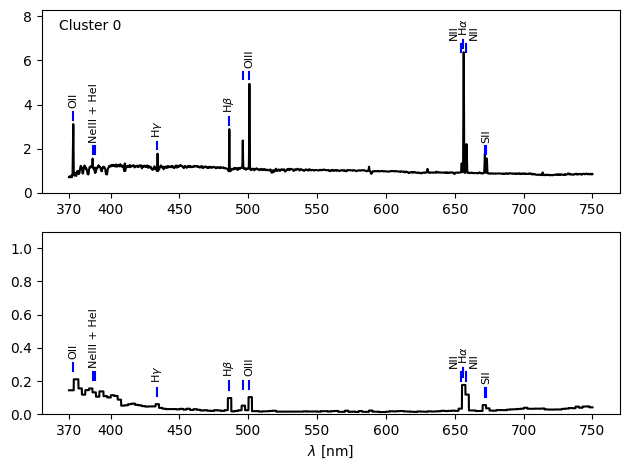

In [59]:
n_segments = 150
label = 0

centroid = score_dict["centroids_top_1_percent"][label, :]

centroid = clustering.expand_weights_per_segments(
    centroid.reshape(1, -1),
    wave.size,
    n_segments,
)

centroid = centroid.reshape(-1)
avg_spectrum = spectra_cluster_dict[label].mean(axis=0)

fig, axs = plt.subplots(
    nrows=2, ncols=1,
    figsize=None,
    tight_layout=True,
)

# # set minor ticks on
# for ax in axs.flatten(): ax.minorticks_on()

axs[0], _ = spec_photo_thumbnail(
    axs[0], wave, avg_spectrum,
    None,
    y_lim_factor=1.3,
    add_image=False,
)
axs[0].text(
    0.03, 0.95,
    f'Cluster {label}', 
    transform=axs[0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# flux_ticks = range(0, 9, 2)
# axs[0].set_yticks(flux_ticks)

axs[0] = add_line_indicators(
    axs[0], wave, avg_spectrum,
    delta=1,
    indicator_starts=0.2,
    indicator_height=0.35,
    add_ne3_he1=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

# weights
axs[1], _ = spec_photo_thumbnail(
    axs[1], wave, centroid,
    None,
    y_lim_factor=1.2,
    add_image=False,
)

axs[1] = add_line_indicators(
    axs[1], wave, centroid,
    delta=1,
    indicator_starts=0.05,
    indicator_height=0.05,
    add_ne3_he1=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

axs[1].set_ylim(0, 1.1)
axs[1].set_xlabel(r"$\lambda$ [nm]")

# fig.suptitle(
#     f"Cluster {label}",
#     fontsize=12,
# )

plot_name = f'top_1_percent_avg_spec_centroid_{label}'

fig.savefig(
    f"{kmeans_model_dir}/{plot_name}.pdf", bbox_inches="tight"
)
fig.savefig(
    f"{save_to_paper_figures}/{plot_name}.pdf", bbox_inches="tight"
)
fig.savefig(
    f"{submission_dir}/{plot_name}.pdf", bbox_inches="tight"
)

# Cluster 4

Base size: 25, Residual size: 23
New number of segments: 151


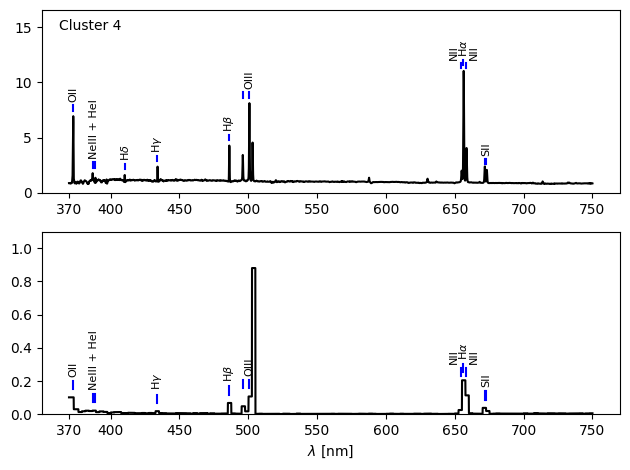

In [65]:
n_segments = 150
label = 4

centroid = score_dict["centroids_top_1_percent"][label, :]

centroid = clustering.expand_weights_per_segments(
    centroid.reshape(1, -1),
    wave.size,
    n_segments,
)

centroid = centroid.reshape(-1)
avg_spectrum = spectra_cluster_dict[label].mean(axis=0)

fig, axs = plt.subplots(
    nrows=2, ncols=1,
    figsize=None,
    tight_layout=True,
)

# # set minor ticks on
# for ax in axs.flatten(): ax.minorticks_on()

axs[0], _ = spec_photo_thumbnail(
    axs[0], wave, avg_spectrum,
    None,
    y_lim_factor=1.5,
    add_image=False,
)

axs[0].text(
    0.03, 0.95,
    f'Cluster {label}', 
    transform=axs[0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# flux_ticks = range(0, 6, 1)
# axs[0].set_yticks(flux_ticks)

axs[0] = add_line_indicators(
    axs[0], wave, avg_spectrum,
    delta=1,
    indicator_starts=0.5,
    indicator_height=0.5,
    add_ne3_he1=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

# weights
axs[1], _ = spec_photo_thumbnail(
    axs[1], wave, centroid,
    None,
    y_lim_factor=1.2,
    add_image=False,
)

axs[1] = add_line_indicators(
    axs[1], wave, centroid,
    delta=1,
    indicator_starts=0.05,
    indicator_height=0.05,
    add_ne3_he1=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

axs[1].set_ylim(0, 1.1)
axs[1].set_xlabel(r"$\lambda$ [nm]")

plot_name = f'top_1_percent_avg_spec_centroid_{label}'

fig.savefig(
    f"{kmeans_model_dir}/{plot_name}.pdf", bbox_inches="tight"
)
fig.savefig(
    f"{save_to_paper_figures}/{plot_name}.pdf", bbox_inches="tight"
)
fig.savefig(
    f"{submission_dir}/{plot_name}.pdf", bbox_inches="tight"
)

# Cluster 5

Base size: 25, Residual size: 23
New number of segments: 151


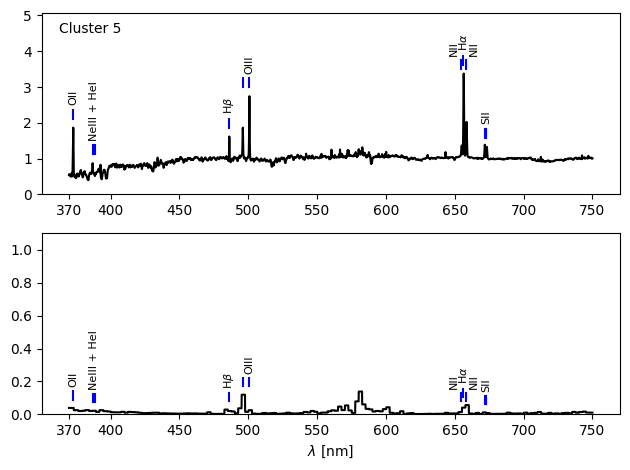

In [64]:
n_segments = 150
label = 5

centroid = score_dict["centroids_top_1_percent"][label, :]

centroid = clustering.expand_weights_per_segments(
    centroid.reshape(1, -1),
    wave.size,
    n_segments,
)

centroid = centroid.reshape(-1)
avg_spectrum = spectra_cluster_dict[label].mean(axis=0)

fig, axs = plt.subplots(
    nrows=2, ncols=1,
    figsize=None,
    tight_layout=True,
)

# # set minor ticks on
# for ax in axs.flatten(): ax.minorticks_on()

axs[0], _ = spec_photo_thumbnail(
    axs[0], wave, avg_spectrum,
    None,
    y_lim_factor=1.5,
    add_image=False,
)

axs[0].text(
    0.03, 0.95,
    f'Cluster {label}', 
    transform=axs[0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# flux_ticks = range(0, 6, 1)
# axs[0].set_yticks(flux_ticks)

axs[0] = add_line_indicators(
    axs[0], wave, avg_spectrum,
    delta=1,
    indicator_starts=0.25,
    indicator_height=0.25,
    add_ne3_he1=True,
    add_h_beta=True,
    add_sii=True
)

# weights
axs[1], _ = spec_photo_thumbnail(
    axs[1], wave, centroid,
    None,
    y_lim_factor=1.2,
    add_image=False,
)

axs[1] = add_line_indicators(
    axs[1], wave, centroid,
    delta=5,
    indicator_starts=0.05,
    indicator_height=0.05,
    add_ne3_he1=True,
    add_h_beta=True,
    add_sii=True
)

axs[1].set_ylim(0, 1.1)
axs[1].set_xlabel(r"$\lambda$ [nm]")

plot_name = f'top_1_percent_avg_spec_centroid_{label}'

fig.savefig(
    f"{kmeans_model_dir}/{plot_name}.pdf", bbox_inches="tight"
)
fig.savefig(
    f"{save_to_paper_figures}/{plot_name}.pdf", bbox_inches="tight"
)
fig.savefig(
    f"{submission_dir}/{plot_name}.pdf", bbox_inches="tight"
)

# Cluster 6

Base size: 25, Residual size: 23
New number of segments: 151


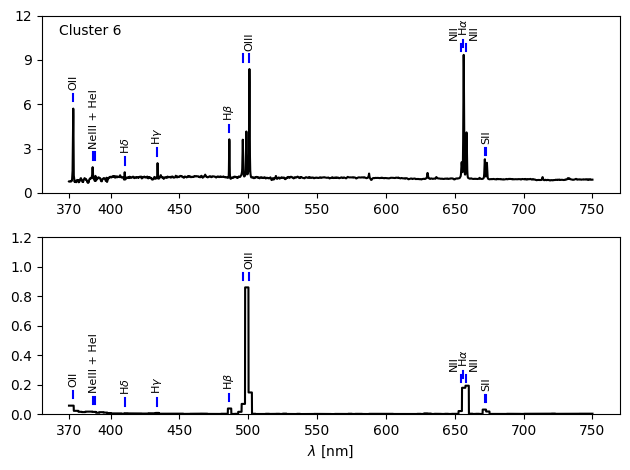

In [63]:
n_segments = 150
label = 6

centroid = score_dict["centroids_top_1_percent"][label, :]

centroid = clustering.expand_weights_per_segments(
    centroid.reshape(1, -1),
    wave.size,
    n_segments,
)

centroid = centroid.reshape(-1)
avg_spectrum = spectra_cluster_dict[label].mean(axis=0)

fig, axs = plt.subplots(
    nrows=2, ncols=1,
    figsize=None,
    tight_layout=True,
)

# # set minor ticks on
# for ax in axs.flatten(): ax.minorticks_on()

axs[0], _ = spec_photo_thumbnail(
    axs[0], wave, avg_spectrum,
    None,
    y_lim_factor=1,
    add_image=False,
)
axs[0].text(
    0.03, 0.95,
    f'Cluster {label}', 
    transform=axs[0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
flux_ticks = range(0, 13, 3)
axs[0].set_yticks(flux_ticks)

axs[0] = add_line_indicators(
    axs[0], wave, avg_spectrum,
    delta=1,
    indicator_starts=0.5,
    indicator_height=0.5,
    add_ne3_he1=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

# weights
axs[1], _ = spec_photo_thumbnail(
    axs[1], wave, centroid,
    None,
    y_lim_factor=1.2,
    add_image=False,
)

axs[1] = add_line_indicators(
    axs[1], wave, centroid,
    delta=5,
    indicator_starts=0.05,
    indicator_height=0.05,
    add_ne3_he1=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

axs[1].set_ylim(0, 1.2)
axs[1].set_xlabel(r"$\lambda$ [nm]")

plot_name = f'top_1_percent_avg_spec_centroid_{label}'

fig.savefig(
    f"{kmeans_model_dir}/{plot_name}.pdf", bbox_inches="tight"
)
fig.savefig(
    f"{save_to_paper_figures}/{plot_name}.pdf", bbox_inches="tight"
)
fig.savefig(
    f"{submission_dir}/{plot_name}.pdf", bbox_inches="tight"
)

# Cluster 1

Base size: 25, Residual size: 23
New number of segments: 151


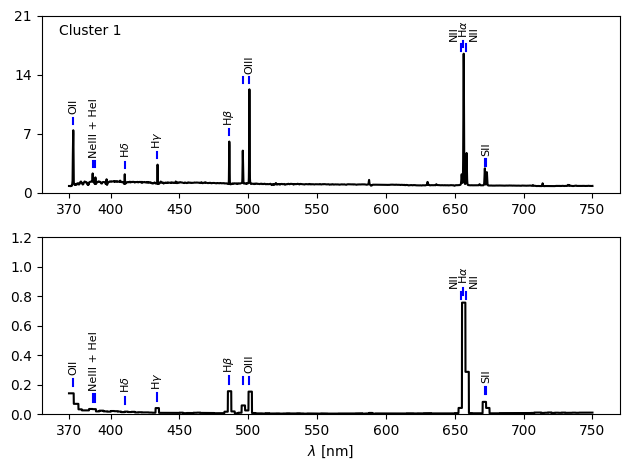

In [70]:
n_segments = 150
label = 1

centroid = score_dict["centroids_top_1_percent"][label, :]

centroid = clustering.expand_weights_per_segments(
    centroid.reshape(1, -1),
    wave.size,
    n_segments,
)

centroid = centroid.reshape(-1)
avg_spectrum = spectra_cluster_dict[label].mean(axis=0)

fig, axs = plt.subplots(
    nrows=2, ncols=1,
    figsize=None,
    tight_layout=True,
)

# # set minor ticks on
# for ax in axs.flatten(): ax.minorticks_on()

axs[0], _ = spec_photo_thumbnail(
    axs[0], wave, avg_spectrum,
    None,
    y_lim_factor=1,
    add_image=False,
)
axs[0].text(
    0.03, 0.95,
    f'Cluster {label}', 
    transform=axs[0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
flux_ticks = range(0, 22, 7)
axs[0].set_yticks(flux_ticks)

axs[0] = add_line_indicators(
    axs[0], wave, avg_spectrum,
    delta=1,
    indicator_starts=0.75,
    indicator_height=0.75,
    add_ne3_he1=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

# weights
axs[1], _ = spec_photo_thumbnail(
    axs[1], wave, centroid,
    None,
    y_lim_factor=1.2,
    add_image=False,
)

axs[1] = add_line_indicators(
    axs[1], wave, centroid,
    delta=5,
    indicator_starts=0.05,
    indicator_height=0.05,
    add_ne3_he1=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

axs[1].set_ylim(0, 1.2)
axs[1].set_xlabel(r"$\lambda$ [nm]")

plot_name = f'top_1_percent_avg_spec_centroid_{label}'

fig.savefig(
    f"{kmeans_model_dir}/{plot_name}.pdf", bbox_inches="tight"
)
fig.savefig(
    f"{save_to_paper_figures}/{plot_name}.pdf", bbox_inches="tight"
)
fig.savefig(
    f"{submission_dir}/{plot_name}.pdf", bbox_inches="tight"
)

# Cluster 2

Base size: 25, Residual size: 23
New number of segments: 151


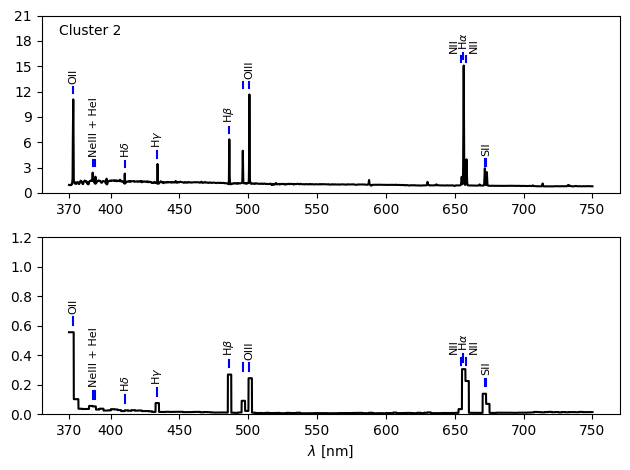

In [72]:
n_segments = 150
label = 2

centroid = score_dict["centroids_top_1_percent"][label, :]

centroid = clustering.expand_weights_per_segments(
    centroid.reshape(1, -1),
    wave.size,
    n_segments,
)

centroid = centroid.reshape(-1)
avg_spectrum = spectra_cluster_dict[label].mean(axis=0)

fig, axs = plt.subplots(
    nrows=2, ncols=1,
    figsize=None,
    tight_layout=True,
)

# # set minor ticks on
# for ax in axs.flatten(): ax.minorticks_on()

axs[0], _ = spec_photo_thumbnail(
    axs[0], wave, avg_spectrum,
    None,
    y_lim_factor=1,
    add_image=False,
)
axs[0].text(
    0.03, 0.95,
    f'Cluster {label}', 
    transform=axs[0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
flux_ticks = range(0, 22, 3)
axs[0].set_yticks(flux_ticks)

axs[0] = add_line_indicators(
    axs[0], wave, avg_spectrum,
    delta=1,
    indicator_starts=0.75,
    indicator_height=0.75,
    add_ne3_he1=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

# weights
axs[1], _ = spec_photo_thumbnail(
    axs[1], wave, centroid,
    None,
    y_lim_factor=1.2,
    add_image=False,
)

axs[1] = add_line_indicators(
    axs[1], wave, centroid,
    delta=5,
    indicator_starts=0.05,
    indicator_height=0.05,
    add_ne3_he1=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

axs[1].set_ylim(0, 1.2)
axs[1].set_xlabel(r"$\lambda$ [nm]")

plot_name = f'top_1_percent_avg_spec_centroid_{label}'

fig.savefig(
    f"{kmeans_model_dir}/{plot_name}.pdf", bbox_inches="tight"
)
fig.savefig(
    f"{save_to_paper_figures}/{plot_name}.pdf", bbox_inches="tight"
)
fig.savefig(
    f"{submission_dir}/{plot_name}.pdf", bbox_inches="tight"
)

# Cluster 3

Base size: 25, Residual size: 23
New number of segments: 151


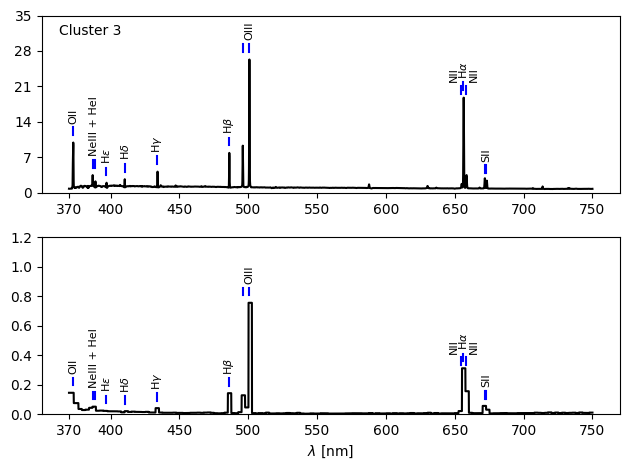

In [78]:
n_segments = 150
label = 3

centroid = score_dict["centroids_top_1_percent"][label, :]

centroid = clustering.expand_weights_per_segments(
    centroid.reshape(1, -1),
    wave.size,
    n_segments,
)

centroid = centroid.reshape(-1)
avg_spectrum = spectra_cluster_dict[label].mean(axis=0)

fig, axs = plt.subplots(
    nrows=2, ncols=1,
    figsize=None,
    tight_layout=True,
)

# # set minor ticks on
# for ax in axs.flatten(): ax.minorticks_on()

axs[0], _ = spec_photo_thumbnail(
    axs[0], wave, avg_spectrum,
    None,
    y_lim_factor=1,
    add_image=False,
)
axs[0].text(
    0.03, 0.95,
    f'Cluster {label}', 
    transform=axs[0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
flux_ticks = range(0, 36, 7)
axs[0].set_yticks(flux_ticks)

axs[0] = add_line_indicators(
    axs[0], wave, avg_spectrum,
    delta=1,
    indicator_starts=1.5,
    indicator_height=1.5,
    add_ne3_he1=True,
    add_h_epsilon=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

# weights
axs[1], _ = spec_photo_thumbnail(
    axs[1], wave, centroid,
    None,
    y_lim_factor=1.2,
    add_image=False,
)

axs[1] = add_line_indicators(
    axs[1], wave, centroid,
    delta=5,
    indicator_starts=0.05,
    indicator_height=0.05,
    add_ne3_he1=True,
    add_h_epsilon=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

axs[1].set_ylim(0, 1.2)
axs[1].set_xlabel(r"$\lambda$ [nm]")

plot_name = f'top_1_percent_avg_spec_centroid_{label}'

fig.savefig(
    f"{kmeans_model_dir}/{plot_name}.pdf", bbox_inches="tight"
)
fig.savefig(
    f"{save_to_paper_figures}/{plot_name}.pdf", bbox_inches="tight"
)
fig.savefig(
    f"{submission_dir}/{plot_name}.pdf", bbox_inches="tight"
)

# Cluster 0 - 4 - 5 -6

## Cluster 0 Data

In [14]:
n_segments = 150
label = 0

centroid_0 = score_dict["centroids_top_1_percent"][label, :]

centroid_0 = clustering.expand_weights_per_segments(
    centroid_0.reshape(1, -1),
    wave.size,
    n_segments,
)

centroid_0 = centroid_0.reshape(-1)
avg_spectrum_0 = spectra_cluster_dict[label].mean(axis=0)


Base size: 25, Residual size: 23
New number of segments: 151


## Cluster 4 Data

In [15]:
n_segments = 150
label = 4

centroid_4 = score_dict["centroids_top_1_percent"][label, :]

centroid_4 = clustering.expand_weights_per_segments(
    centroid_4.reshape(1, -1),
    wave.size,
    n_segments,
)

centroid_4 = centroid_4.reshape(-1)
avg_spectrum_4 = spectra_cluster_dict[label].mean(axis=0)


Base size: 25, Residual size: 23
New number of segments: 151


## Cluster 5 Data

In [16]:
n_segments = 150
label = 5

centroid_5 = score_dict["centroids_top_1_percent"][label, :]

centroid_5 = clustering.expand_weights_per_segments(
    centroid_5.reshape(1, -1),
    wave.size,
    n_segments,
)

centroid_5 = centroid_5.reshape(-1)
avg_spectrum_5 = spectra_cluster_dict[label].mean(axis=0)


Base size: 25, Residual size: 23
New number of segments: 151


## Cluster 6 Data

In [17]:
n_segments = 150
label = 6

centroid_6 = score_dict["centroids_top_1_percent"][label, :]

centroid_6 = clustering.expand_weights_per_segments(
    centroid_6.reshape(1, -1),
    wave.size,
    n_segments,
)

centroid_6 = centroid_6.reshape(-1)
avg_spectrum_6 = spectra_cluster_dict[label].mean(axis=0)


Base size: 25, Residual size: 23
New number of segments: 151


## Plot 0-4-5-6 

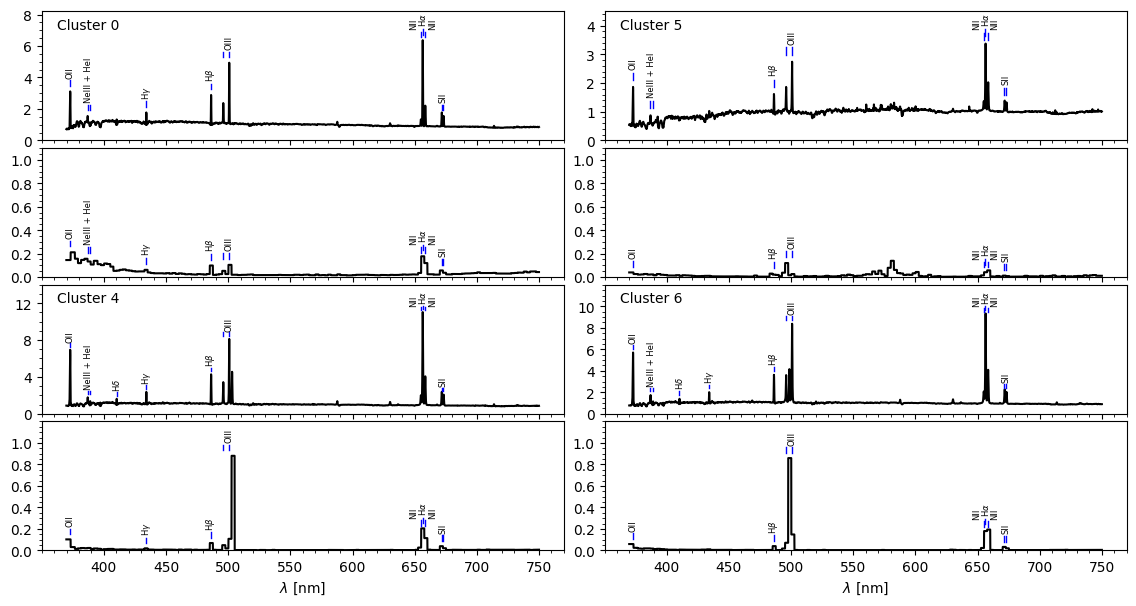

In [ ]:
fig, axs = plt.subplots(
    4, 2,
    sharex=True,
    figsize=(14, 7)
)
width_height_image = '100%'
# -------------------------------------------------
# Cluster_0
axs[0, 0] = spec_photo_thumbnail(
    axs[0, 0], wave, avg_spectrum_0,
    None,
    add_image=False,
)
axs[0, 0].text(
    0.03, 0.95,
    f'Cluster 0 - Average spectrum', 
    transform=axs[0, 0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# 
axs[0, 0].set_ylim(0, 8.2) 
avg_spec_0_ticks = [0, 2, 4, 6, 8]
axs[0, 0].set_yticks(avg_spec_0_ticks)

axs[0, 0] = add_line_indicators(
    axs[0, 0], wave, avg_spectrum_0,
    indicator_starts=0.35,
    indicator_height=0.35,
    add_ne3_he1=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

# weights
axs[1, 0] = spec_photo_thumbnail(
    axs[1, 0], wave, centroid_0,
    None,
    add_image=False,
)
axs[1, 0].set_ylim(0, 1.1) 
cluster_0_ticks = [0, 0.2, 0.4, 0.6, 0.8, 1]
axs[1, 0].set_yticks(cluster_0_ticks)

axs[1, 0] = add_line_indicators(
    axs[1, 0], wave, centroid_0,
    delta=1,
    indicator_starts=0.05,
    indicator_height=0.05,
    add_ne3_he1=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)
axs[1, 0].text(
    0.03, 0.95,
    f'Cluster 0 - Average weights', 
    transform=axs[1, 0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# -------------------------------------------------
# Cluster_4
axs[2, 0] = spec_photo_thumbnail(
    axs[2, 0], wave, avg_spectrum_4,
    None,
    add_image=False,
)
axs[2, 0].text(
    0.03, 0.95,
    f'Cluster 4 - Average spectrum'', 
    transform=axs[2, 0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# 
axs[2, 0].set_ylim(0, 14) 
avg_spec_4_ticks = [0, 4, 8, 12]
axs[2, 0].set_yticks(avg_spec_4_ticks)

axs[2, 0] = add_line_indicators(
    axs[2, 0], wave, avg_spectrum_4,
    indicator_starts=0.35,
    indicator_height=0.35,
    add_ne3_he1=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

# weights
axs[3, 0] = spec_photo_thumbnail(
    axs[3, 0], wave, centroid_4,
    None,
    add_image=False,
)
axs[3, 0].set_ylim(0, 1.2) 
cluster_4_ticks = [0, 0.2, 0.4, 0.6, 0.8, 1]
axs[3, 0].set_yticks(cluster_4_ticks)

axs[3, 0] = add_line_indicators(
    axs[3, 0], wave, centroid_4,
    delta=3,
    indicator_starts=0.05,
    indicator_height=0.05,
    add_ne3_he1=False,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

axs[3, 0].text(
    0.03, 0.95,
    f'Cluster 4 - Average weights'', 
    transform=axs[3, 0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)

# -------------------------------------------------
# Cluster_5
axs[0, 1] = spec_photo_thumbnail(
    axs[0, 1], wave, avg_spectrum_5,
    None,
    add_image=False,
)
axs[0, 1].text(
    0.03, 0.95,
    f'Cluster 5 - Average spectrum', 
    transform=axs[0, 1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# 
axs[0, 1].set_ylim(0, 4.5) 
avg_spec_5_ticks = [0, 1, 2, 3, 4]
axs[0, 1].set_yticks(avg_spec_5_ticks)

axs[0, 1] = add_line_indicators(
    axs[0, 1], wave, avg_spectrum_5,
    indicator_starts=0.25,
    indicator_height=0.25,
    add_ne3_he1=True,
    add_h_gamma=False,
    add_h_beta=True,
    add_sii=True
)
# weights
axs[1, 1] = spec_photo_thumbnail(
    axs[1, 1], wave, centroid_5,
    None,
    add_image=False,
)
axs[1, 1].set_ylim(0, 1.1) 
cluster_5_ticks = [0, 0.2, 0.4, 0.6, 0.8, 1]
axs[1, 1].set_yticks(cluster_5_ticks)

axs[1, 1] = add_line_indicators(
    axs[1, 1], wave, centroid_5,
    delta=4,
    indicator_starts=0.05,
    indicator_height=0.05,
    add_ne3_he1=False,
    add_h_gamma=False,
    add_h_beta=True,
    add_sii=True
)

axs[1, 1].text(
    0.03, 0.95,
    f'Cluster 5 - Average weights', 
    transform=axs[1, 1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)

# -------------------------------------------------
# Cluster_6
axs[2, 1] = spec_photo_thumbnail(
    axs[2, 1], wave, avg_spectrum_6,
    None,
    add_image=False,
)
axs[2, 1].text(
    0.03, 0.95,
    f'Cluster 6 - Average spectrum', 
    transform=axs[2, 1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# 
axs[2, 1].set_ylim(0, 12) 
avg_spec_6_ticks = [0, 2, 4, 6,8, 10]
axs[2, 1].set_yticks(avg_spec_6_ticks)

axs[2, 1] = add_line_indicators(
    axs[2, 1], wave, avg_spectrum_6,
    indicator_starts=0.35,
    indicator_height=0.35,
    add_ne3_he1=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

# weights
axs[3, 1] = spec_photo_thumbnail(
    axs[3, 1], wave, centroid_6,
    None,
    add_image=False,
)
axs[3, 1].set_ylim(0, 1.2) 
cluster_6_ticks = [0, 0.2, 0.4, 0.6, 0.8, 1]
axs[3, 1].set_yticks(cluster_6_ticks)

axs[3, 1] = add_line_indicators(
    axs[3, 1], wave, centroid_6,
    delta=3,
    indicator_starts=0.05,
    indicator_height=0.05,
    add_ne3_he1=False,
    add_h_gamma=False,
    add_h_beta=True,
    add_sii=True
)

axs[3, 1].text(
    0.03, 0.95,
    f'Cluster 6 - Average weights', 
    transform=axs[3, 1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)

# -------------------------------------------------
# ---------------------------------------------- 
axs[3, 0].set_xlabel(r"$\lambda$ [nm]")
axs[3, 1].set_xlabel(r"$\lambda$ [nm]")
# 
for ax in axs.flatten(): ax.minorticks_on()

# adjust vertical space
plt.subplots_adjust(
    hspace=0.06,
    wspace=0.078
)

fig.savefig(
    f"{submission_dir}/clusters_0_4_5_6.pdf",
    bbox_inches='tight'
)

# Cluster 1-2

## Cluster 1 data

In [40]:
n_segments = 150
label = 1

centroid_1 = score_dict["centroids_top_1_percent"][label, :]

centroid_1 = clustering.expand_weights_per_segments(
    centroid_1.reshape(1, -1),
    wave.size,
    n_segments,
)

centroid_1 = centroid_1.reshape(-1)
avg_spectrum_1 = spectra_cluster_dict[label].mean(axis=0)


Base size: 25, Residual size: 23
New number of segments: 151


## Cluster 2 data

In [42]:
n_segments = 150
label = 2

centroid_2 = score_dict["centroids_top_1_percent"][label, :]

centroid_2 = clustering.expand_weights_per_segments(
    centroid_2.reshape(1, -1),
    wave.size,
    n_segments,
)

centroid_2 = centroid_2.reshape(-1)
avg_spectrum_2 = spectra_cluster_dict[label].mean(axis=0)


Base size: 25, Residual size: 23
New number of segments: 151


## Plot 1-2

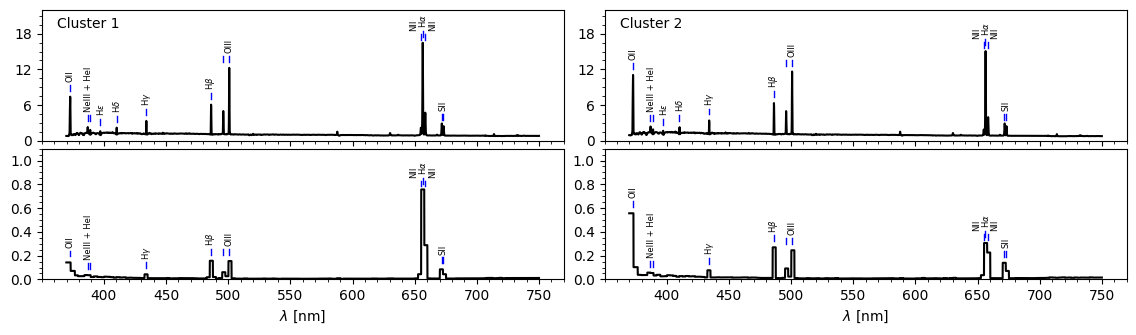

In [52]:
fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    figsize=(14, 3.5)
)
width_height_image = '100%'
# -------------------------------------------------
# Cluster_1
axs[0, 0] = spec_photo_thumbnail(
    axs[0, 0], wave, avg_spectrum_1,
    None,
    add_image=False,
)
axs[0, 0].text(
    0.03, 0.95,
    f'Cluster 1', 
    transform=axs[0, 0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# 
axs[0, 0].set_ylim(0, 22) 
avg_spec_1_ticks = [0, 6, 12, 18]
axs[0, 0].set_yticks(avg_spec_1_ticks)

axs[0, 0] = add_line_indicators(
    axs[0, 0], wave, avg_spectrum_1,
    indicator_starts=1,
    indicator_height=1,
    add_ne3_he1=True,
    add_h_epsilon=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

# weights
axs[1, 0] = spec_photo_thumbnail(
    axs[1, 0], wave, centroid_1,
    None,
    add_image=False,
)
axs[1, 0].set_ylim(0, 1.1) 
cluster_1_ticks = [0, 0.2, 0.4, 0.6, 0.8, 1]
axs[1, 0].set_yticks(cluster_1_ticks)

axs[1, 0] = add_line_indicators(
    axs[1, 0], wave, centroid_1,
    delta=1,
    indicator_starts=0.05,
    indicator_height=0.05,
    add_ne3_he1=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)
# -------------------------------------------------
# Cluster_2
axs[0, 1] = spec_photo_thumbnail(
    axs[0, 1], wave, avg_spectrum_2,
    None,
    add_image=False,
)
axs[0, 1].text(
    0.03, 0.95,
    f'Cluster 2', 
    transform=axs[0, 1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# 
axs[0, 1].set_ylim(0, 22) 
avg_spec_2_ticks = [0, 6, 12, 18]
axs[0, 1].set_yticks(avg_spec_2_ticks)

axs[0, 1] = add_line_indicators(
    axs[0, 1], wave, avg_spectrum_2,
    indicator_starts=1,
    indicator_height=1,
    add_ne3_he1=True,
    add_h_epsilon=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

# weights
axs[1, 1] = spec_photo_thumbnail(
    axs[1, 1], wave, centroid_2,
    None,
    add_image=False,
)
axs[1, 1].set_ylim(0, 1.1) 
cluster_2_ticks = [0, 0.2, 0.4, 0.6, 0.8, 1]
axs[1, 1].set_yticks(cluster_2_ticks)

axs[1, 1] = add_line_indicators(
    axs[1, 1], wave, centroid_2,
    delta=1,
    indicator_starts=0.05,
    indicator_height=0.05,
    add_ne3_he1=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

# ---------------------------------------------- 
axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[1, 1].set_xlabel(r"$\lambda$ [nm]")
# 
for ax in axs.flatten(): ax.minorticks_on()

# adjust vertical space
plt.subplots_adjust(
    hspace=0.06,
    wspace=0.078
)

fig.savefig(
    f"{submission_dir}/clusters_1_2.pdf",
    bbox_inches='tight'
)

# Cluster 3

In [53]:
n_segments = 150
label = 3

centroid_3 = score_dict["centroids_top_1_percent"][label, :]

centroid_3 = clustering.expand_weights_per_segments(
    centroid_3.reshape(1, -1),
    wave.size,
    n_segments,
)

centroid_3 = centroid_3.reshape(-1)
avg_spectrum_3 = spectra_cluster_dict[label].mean(axis=0)


Base size: 25, Residual size: 23
New number of segments: 151


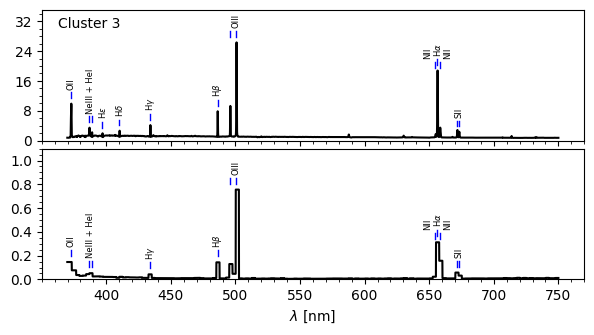

In [59]:
fig, axs = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(7, 3.5)
)
width_height_image = '100%'
# -------------------------------------------------
# Cluster_3
axs[0] = spec_photo_thumbnail(
    axs[0], wave, avg_spectrum_3,
    None,
    add_image=False,
)
axs[0].text(
    0.03, 0.95,
    f'Cluster 3', 
    transform=axs[0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# 
axs[0].set_ylim(0, 35) 
avg_spec_3_ticks = [0, 8, 16, 24, 32]
axs[0].set_yticks(avg_spec_3_ticks)

axs[0] = add_line_indicators(
    axs[0], wave, avg_spectrum_3,
    indicator_starts=1.5,
    indicator_height=1.5,
    add_ne3_he1=True,
    add_h_epsilon=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)

# weights
axs[1] = spec_photo_thumbnail(
    axs[1], wave, centroid_3,
    None,
    add_image=False,
)
axs[1].set_ylim(0, 1.1) 
cluster_3_ticks = [0, 0.2, 0.4, 0.6, 0.8, 1]
axs[1].set_yticks(cluster_3_ticks)

axs[1] = add_line_indicators(
    axs[1], wave, centroid_3,
    delta=1,
    indicator_starts=0.05,
    indicator_height=0.05,
    add_ne3_he1=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True
)
# ---------------------------------------------- 
axs[1].set_xlabel(r"$\lambda$ [nm]")
# 
for ax in axs.flatten(): ax.minorticks_on()

# adjust vertical space
plt.subplots_adjust(
    hspace=0.06,
    wspace=0.078
)

fig.savefig(
    f"{submission_dir}/clusters_3.pdf",
    bbox_inches='tight'
)